# Notebook 03 - Textual Visualization

In this notebook we visualize our data regarding the stories textual informations. 

# 0. Setup

In [1]:
# Libraries

# General
import numpy as np                      # imports the Numpy library for numerical tools
import pandas as pd                     # imports the Pandas library for data manipulation and analysis
from scipy import stats

# Plotting Options
from matplotlib import pyplot as plt                           # imports the Pyplot module from the Matplotlib library for plotting
import seaborn as sns 
plt.rcParams['text.usetex'] = True                             # enables LaTeX rendering for text in plots
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'  # LaTeX preamble

# File management
from pathlib import Path                  # imports path tools from Pathlib for working with file paths
import os                               # imports the OS library for interacting with the operating system

def find_project_root(start=Path.cwd(), marker='data'): # defines a function to find the project root directory by looking for a specific marker (default is 'data')
    current = start
    while current != current.parent:
        if (current / marker).exists():
            return current
        current = current.parent
    raise FileNotFoundError("Project root not found")

PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)

from tools import text_tools # tools for text processing
from tools import dataframe_tools as dftools # tools for dataframe processing

In [2]:
biblio = text_tools.bibliography()  # defines a bibliography object
print( biblio.files )               # lists the files in the directory

['dreams_in_the_witch.txt', 'ex_oblivione.txt', 'poetry_of_gods.txt', 'doorstep.txt', 'colour_out_of_space.txt', 'iranon.txt', 'street.txt', 'arthur_jermyn.txt', 'crawling_chaos.txt', 'ulthar.txt', 'azathoth.txt', 'shadow_out_of_time.txt', 'haunter.txt', 'martins_beach.txt', 'tree.txt', 'whisperer.txt', 'moon_bog.txt', 'unnamable.txt', 'beast.txt', 'alchemist.txt', 'terrible_old_man.txt', 'nameless.txt', 'reanimator.txt', 'celephais.txt', 'gates_of_silver_key.txt', 'medusas_coil.txt', 'dagon.txt', 'picture_house.txt', 'memory.txt', 'white_ship.txt', 'erich_zann.txt', 'tomb.txt', 'temple.txt', 'he.txt', 'pickman.txt', 'silver_key.txt', 'clergyman.txt', 'old_folk.txt', 'from_beyond.txt', 'descendent.txt', 'nyarlathotep.txt', 'vault.txt', 'hypnos.txt', 'polaris.txt', 'book.txt', 'shunned_house.txt', 'pharoahs.txt', 'randolph_carter.txt', 'innsmouth.txt', 'charles_dexter_ward.txt', 'dunwich.txt', 'festival.txt', 'other_gods.txt', 'redhook.txt', 'hound.txt', 'outsider.txt', 'mountains_of_ma

# 1. Text Metadata Visualization

In [3]:
biblio.df_texts.head()  # displays the first few rows of the DataFrame containing the text metadata

,text,file,sentence_count,word_count,vocabulary,character_count
0,dreams_in_the_witch,dreams_in_the_witch.txt,546,14626,4148,86779
1,ex_oblivione,ex_oblivione.txt,21,701,348,3814
2,poetry_of_gods,poetry_of_gods.txt,56,1866,862,10560
3,doorstep,doorstep.txt,422,10446,3297,60265
4,colour_out_of_space,colour_out_of_space.txt,500,12134,3475,68090


Text(0.5, 1.0, 'Word count distribution')

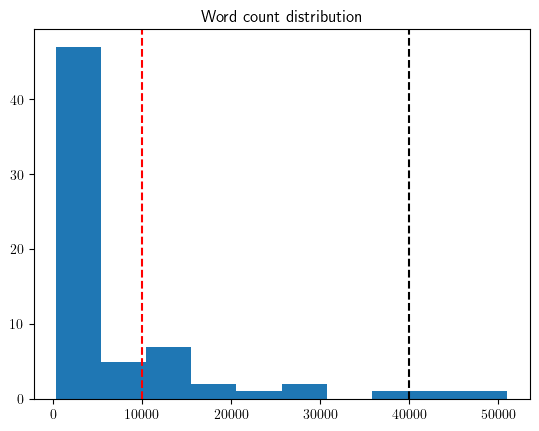

In [4]:
# word count histogram
plt.hist( biblio.df_texts['word_count'])  # creates a histogram of the word counts of the texts
plt.axvline( x = 1e4, color='red', linestyle='--', label='Novella' )
plt.axvline( x = 4e4, color='black', linestyle='--', label='Novel' )
plt.title('Word count distribution')

Text(0.5, 1.0, 'Sentence count distribution')

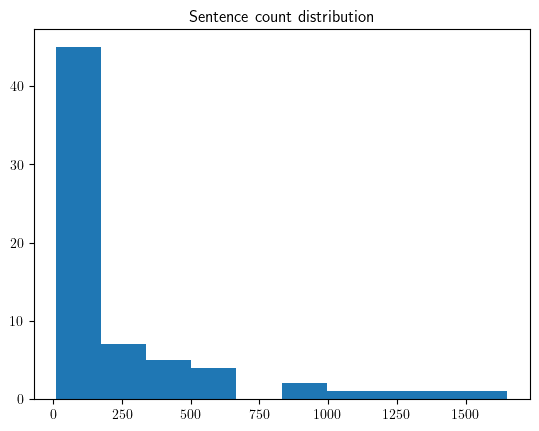

In [5]:
# sentence count histogram
plt.hist( biblio.df_texts['sentence_count'])  # creates a histogram of the sentence counts of the texts
plt.title('Sentence count distribution')

Text(0.5, 1.0, 'Vocabulary size distribution')

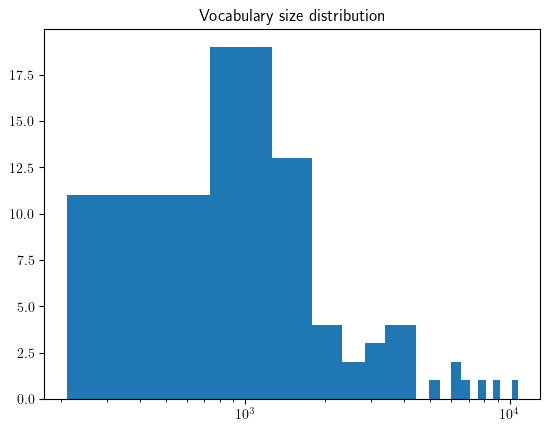

In [6]:
# vocabulary histogram
plt.hist( biblio.df_texts['vocabulary'], bins = 20)  # creates a histogram of the vocabulary sizes of the texts
plt.xscale('log')
plt.title('Vocabulary size distribution')

Text(0.5, 1.0, 'Character count distribution')

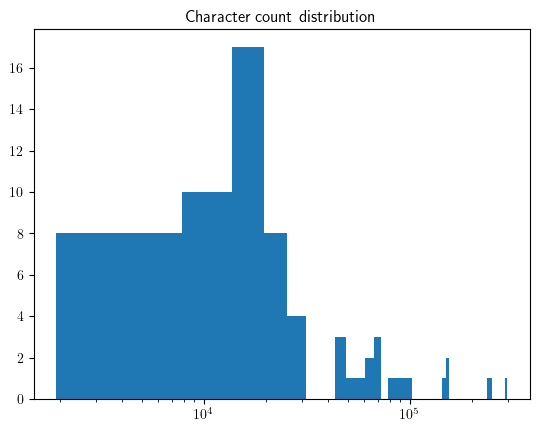

In [7]:
# character count histogram
plt.hist( biblio.df_texts['character_count'], bins = 50)  # creates a histogram of the character counts of the texts
plt.xscale('log') 
plt.title('Character count distribution')

Text(0.5, 1.0, 'Vocabulary to word count ratio distribution')

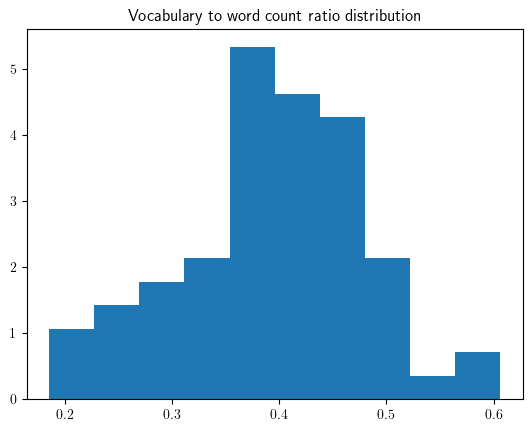

In [8]:
# vocabulary to word count ratio histogram

# vocabulary to word count
vocab_to_word = biblio.df_texts['vocabulary']/biblio.df_texts['word_count']

plt.hist( vocab_to_word, density=True )  # creates a histogram of the vocabulary sizes of the texts
plt.title('Vocabulary to word count ratio distribution')

Text(0.5, 1.0, 'Vocabulary to sentence count ratio distribution')

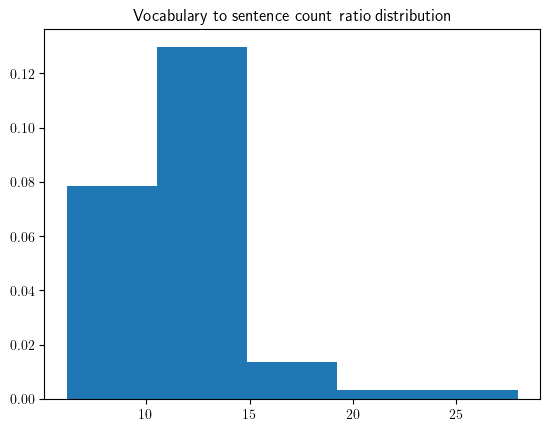

In [9]:
# vocabulary to sentence count 

vocabulary_to_sentence = biblio.df_texts['vocabulary']/biblio.df_texts['sentence_count']

plt.hist(vocabulary_to_sentence, density=True, bins= 5)
plt.title('Vocabulary to sentence count ratio distribution') 

# 2. Story Visualization

In this section we will plot the distribution for each story. We create a dictionary called lenghts in which the keys will be the story names and the value will be a list of the lenght of each sentence in that given story. 

In [10]:
lenghts = {}

for story in biblio.texts:
    lenghts[story] = [len(sentence) for sentence in biblio.sentences[story]]


In [11]:
lenghts

{'dreams_in_the_witch': [128,
  234,
  184,
  226,
  222,
  199,
  257,
  249,
  49,
  334,
  165,
  74,
  115,
  160,
  338,
  82,
  185,
  340,
  86,
  70,
  171,
  560,
  107,
  331,
  229,
  143,
  72,
  199,
  205,
  243,
  205,
  203,
  354,
  91,
  243,
  123,
  218,
  399,
  63,
  280,
  161,
  63,
  206,
  81,
  65,
  286,
  148,
  267,
  287,
  250,
  85,
  155,
  118,
  74,
  313,
  263,
  136,
  361,
  175,
  169,
  229,
  153,
  99,
  297,
  206,
  85,
  156,
  236,
  169,
  78,
  151,
  227,
  272,
  195,
  184,
  171,
  143,
  219,
  210,
  269,
  83,
  131,
  148,
  169,
  208,
  114,
  204,
  384,
  209,
  303,
  226,
  82,
  229,
  303,
  290,
  242,
  164,
  261,
  79,
  84,
  154,
  209,
  436,
  149,
  136,
  123,
  214,
  171,
  179,
  102,
  172,
  288,
  64,
  137,
  159,
  71,
  103,
  56,
  170,
  28,
  146,
  79,
  89,
  165,
  227,
  185,
  132,
  501,
  49,
  153,
  127,
  155,
  105,
  22,
  127,
  261,
  107,
  160,
  149,
  169,
  147,
  171,
  89,
  520

Now we will plot a distribution for each story over its sentence lenghts. 

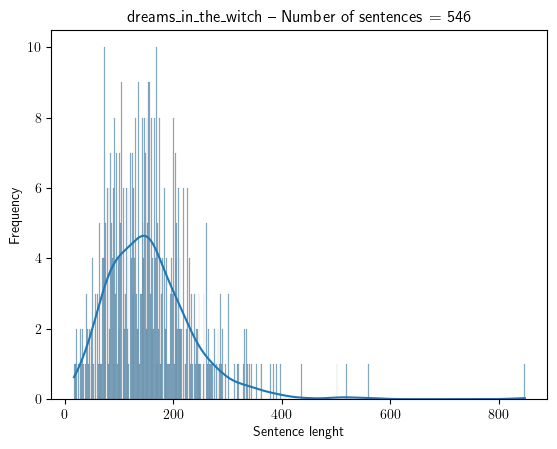

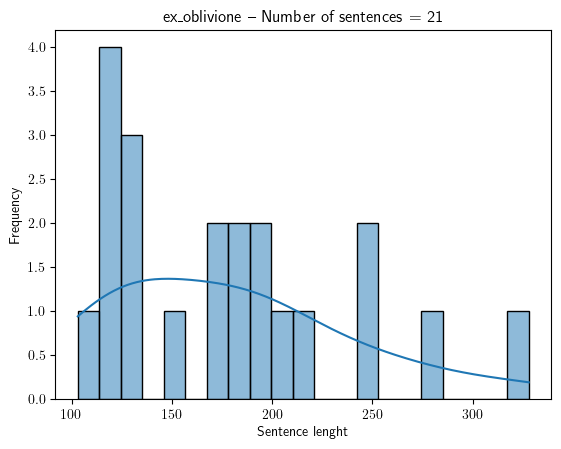

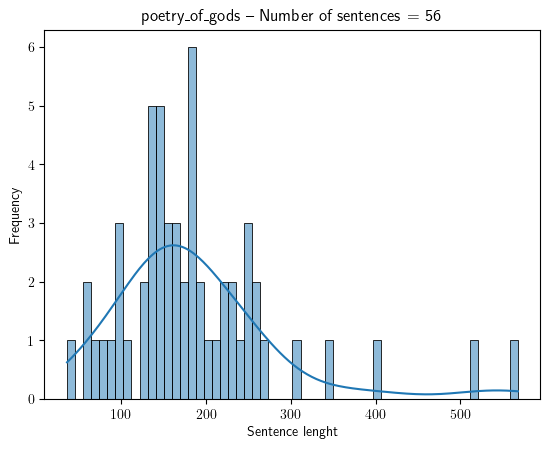

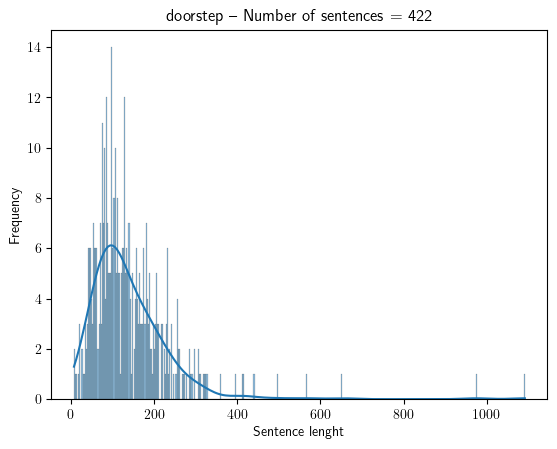

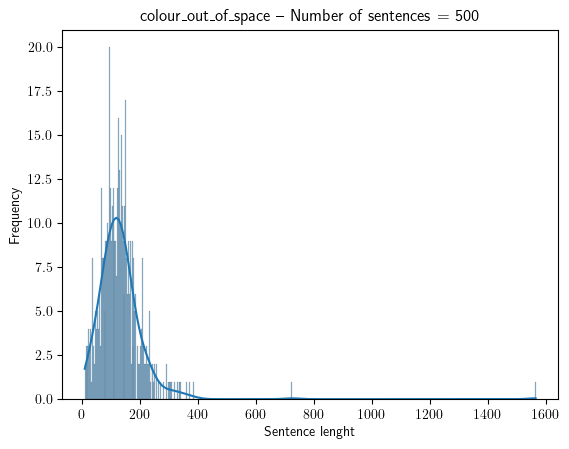

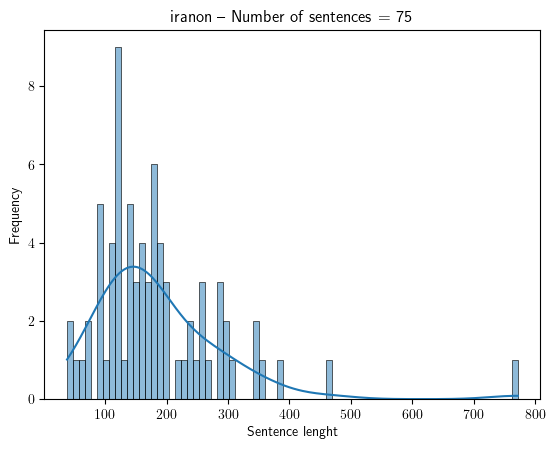

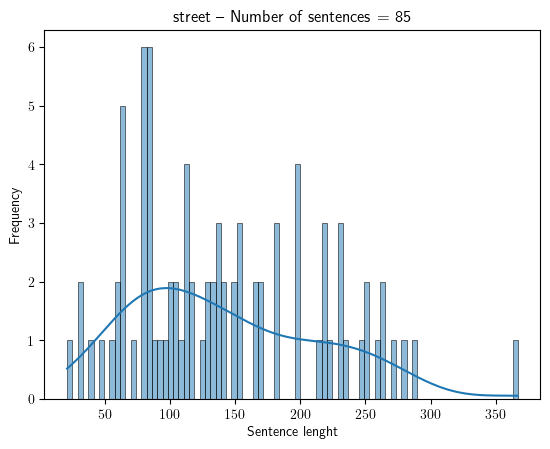

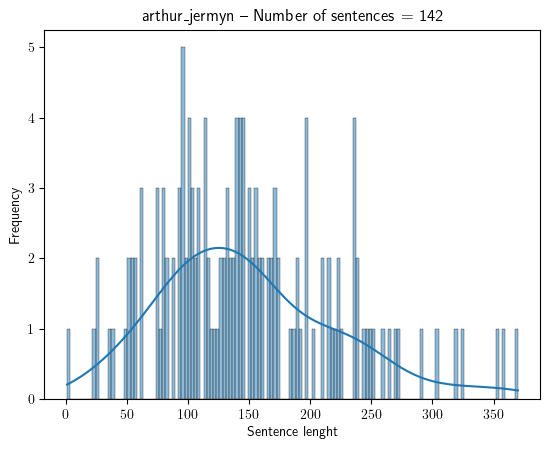

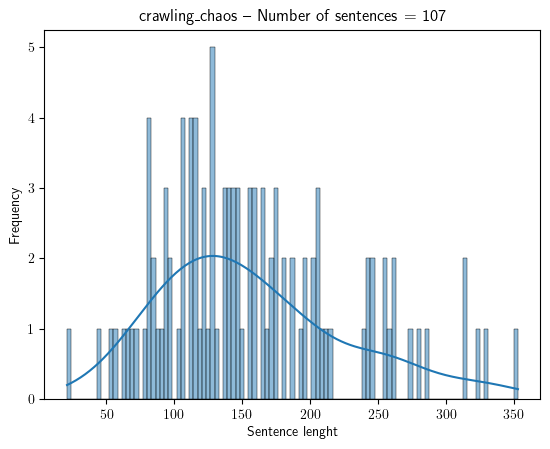

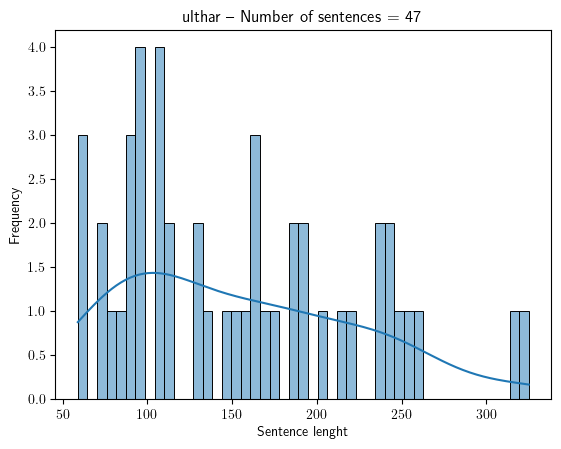

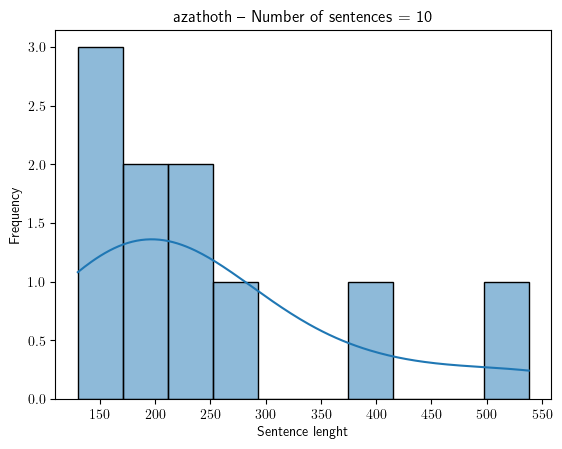

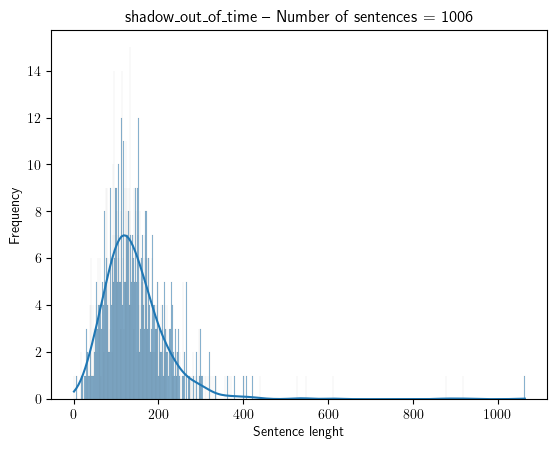

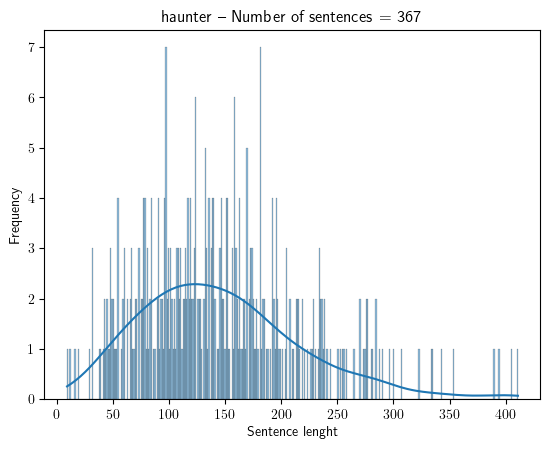

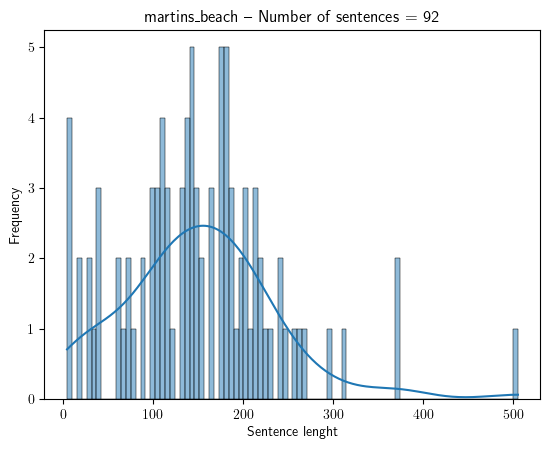

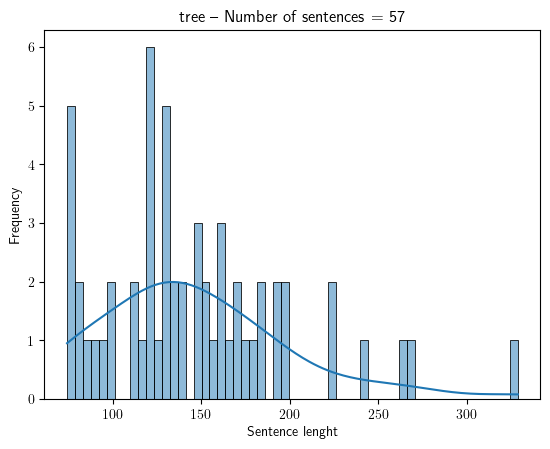

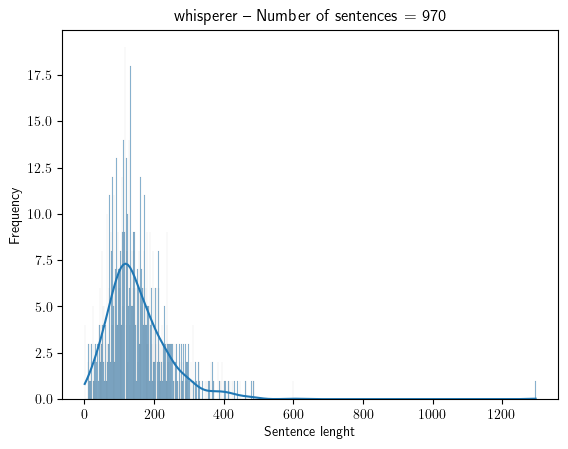

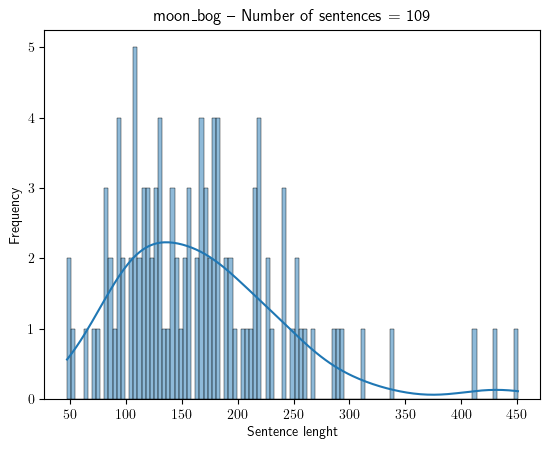

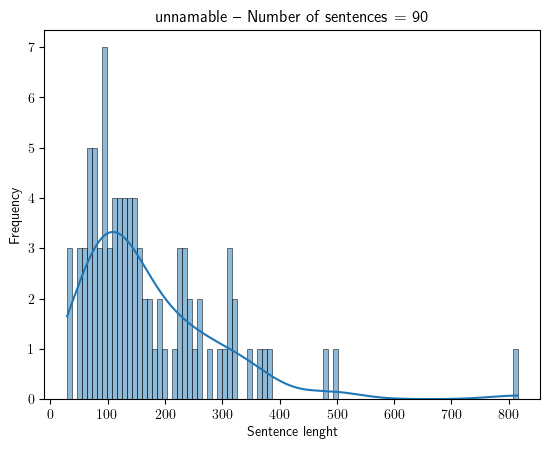

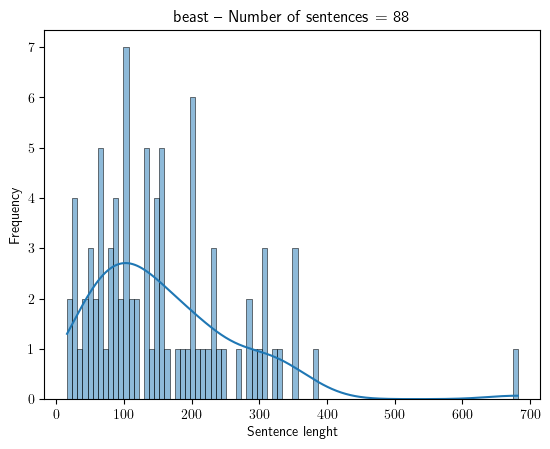

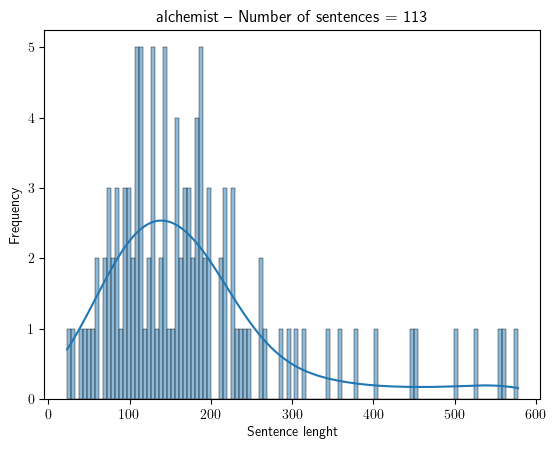

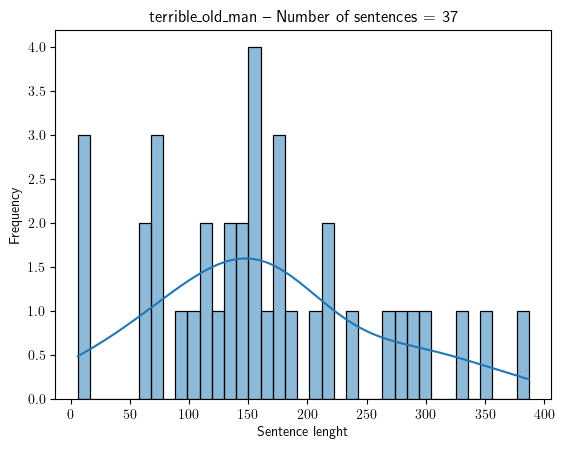

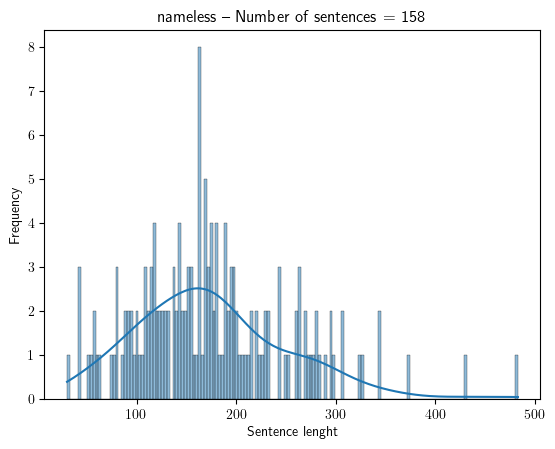

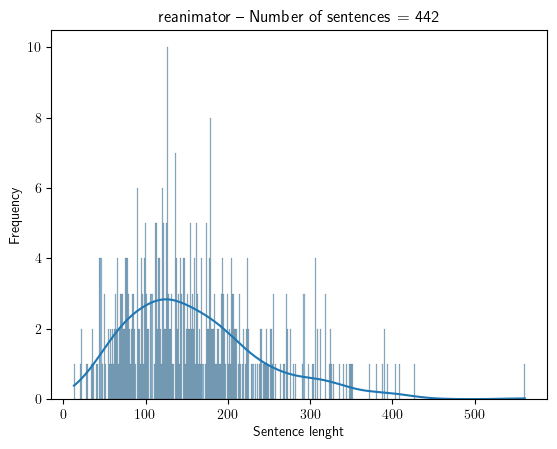

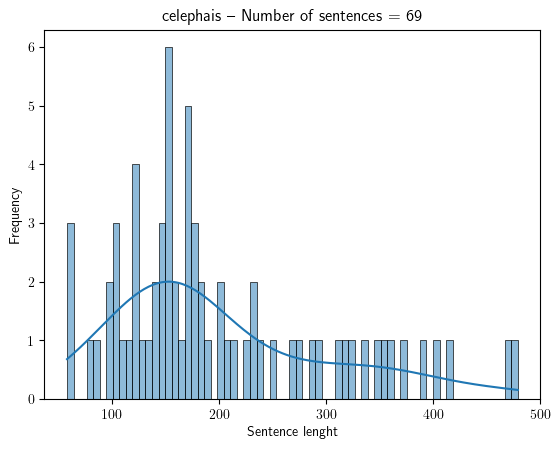

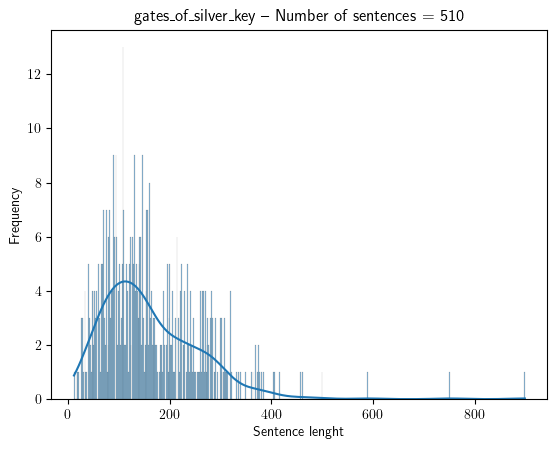

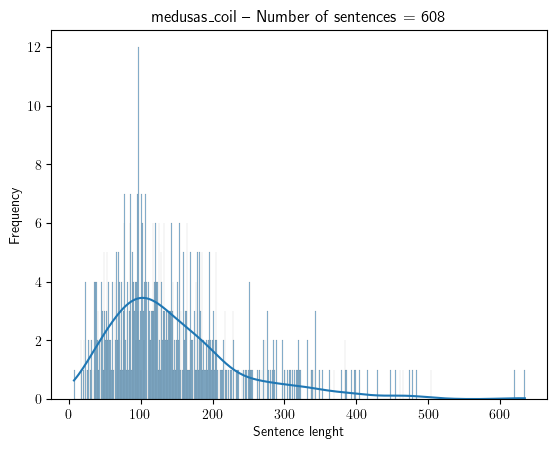

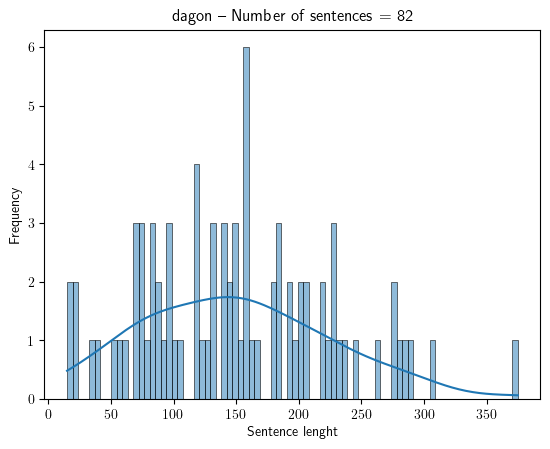

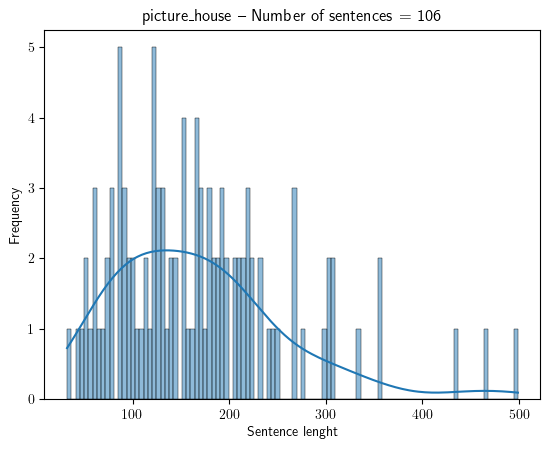

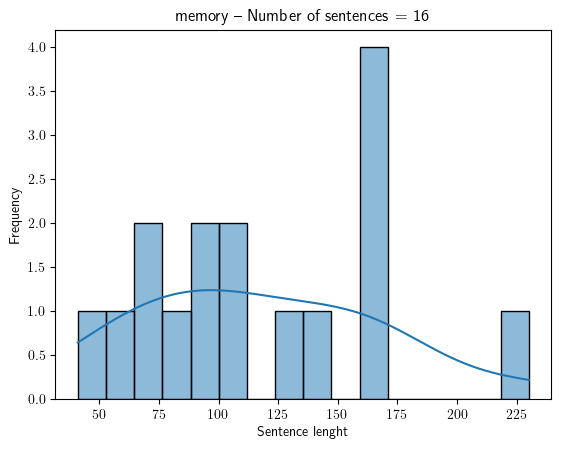

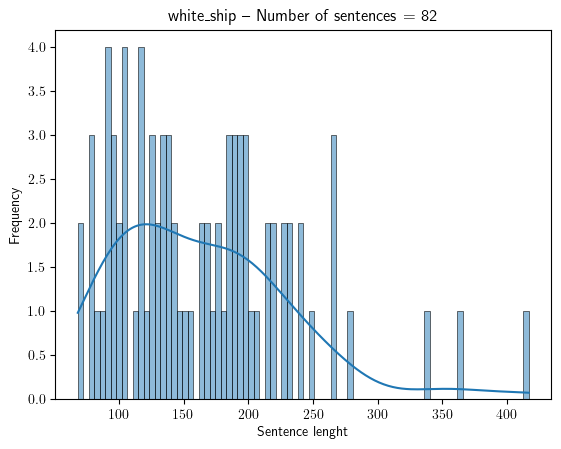

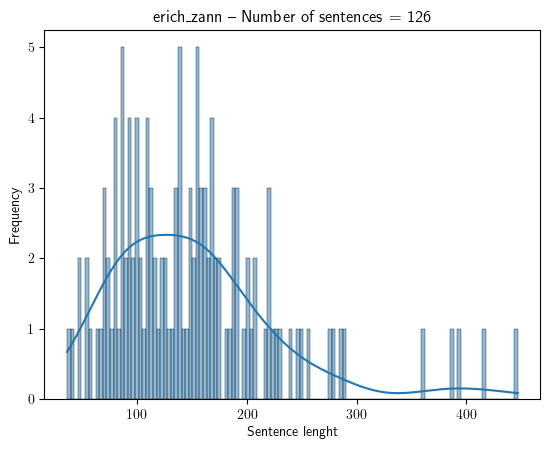

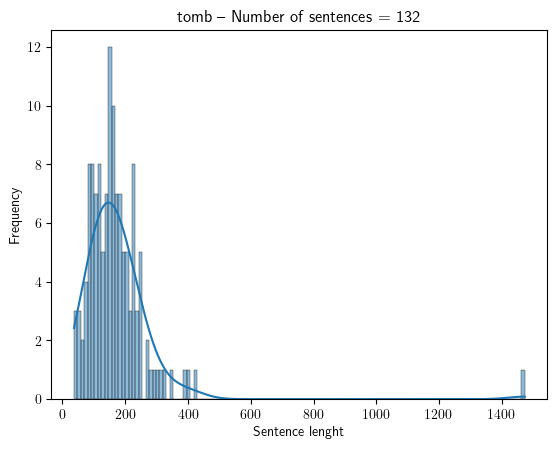

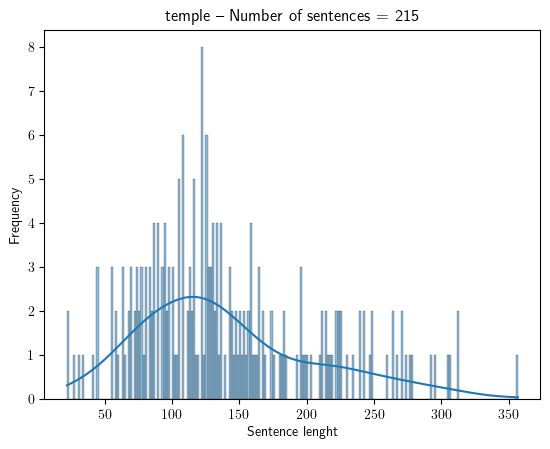

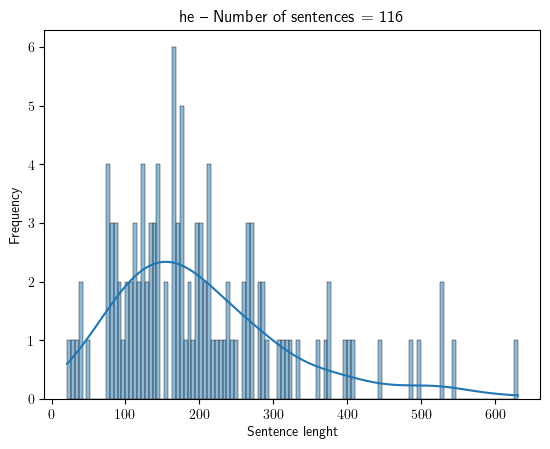

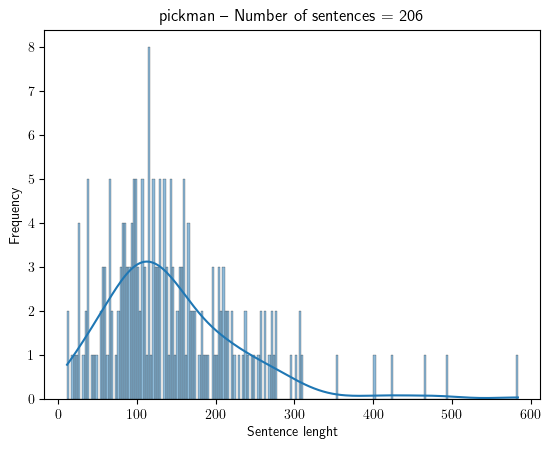

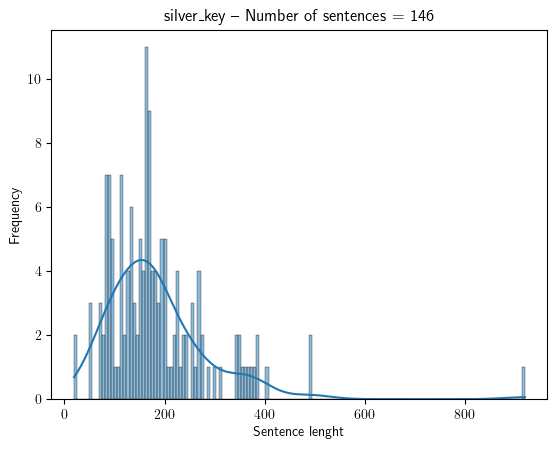

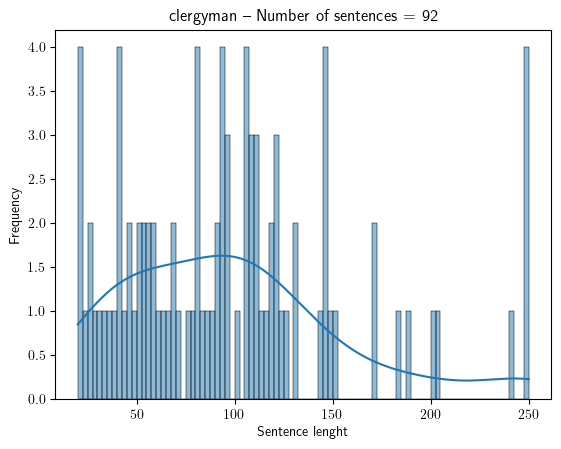

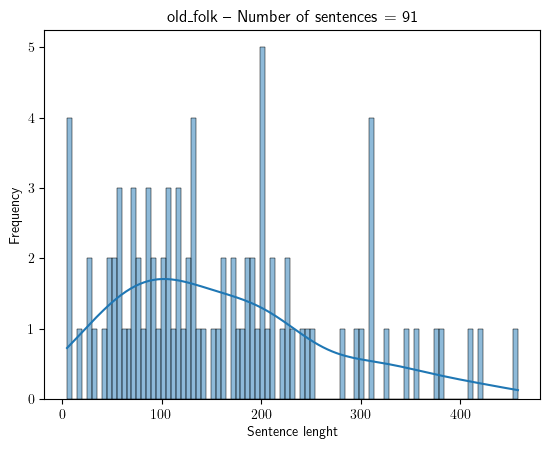

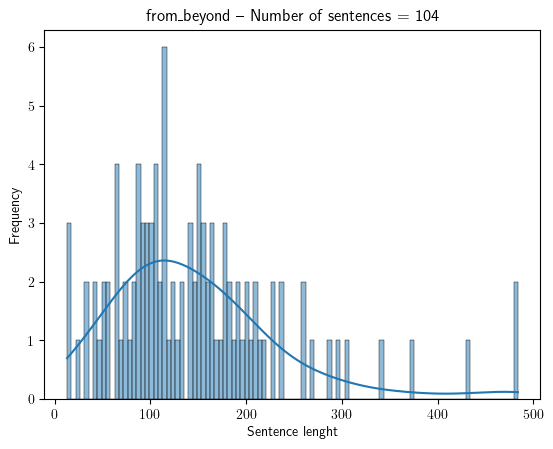

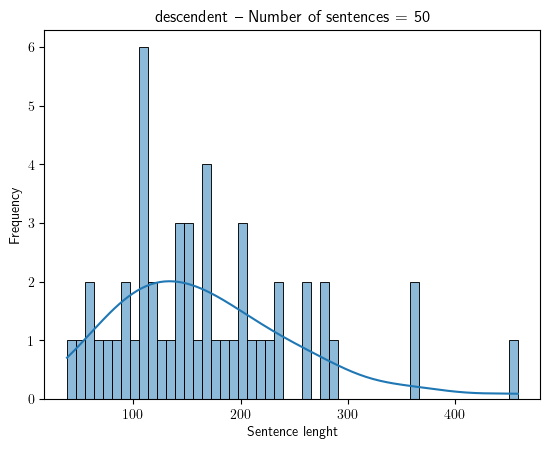

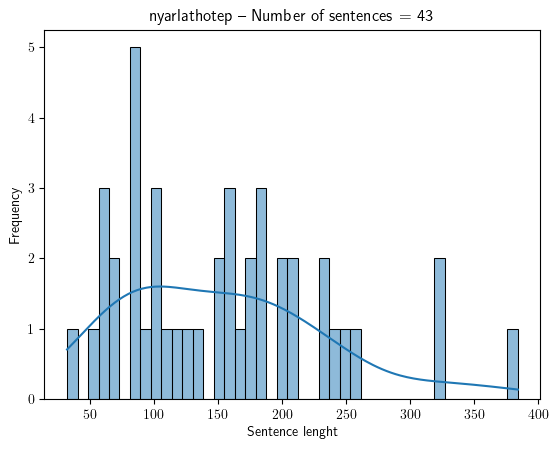

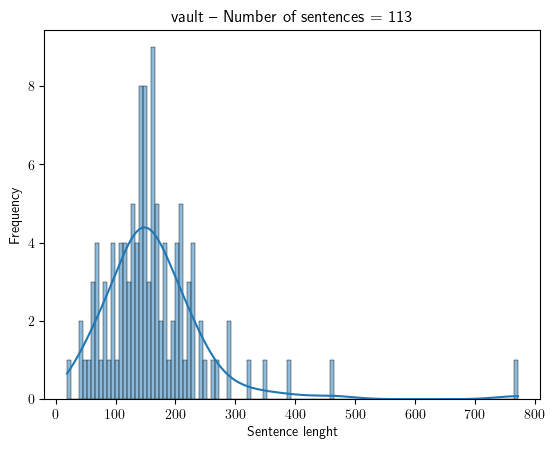

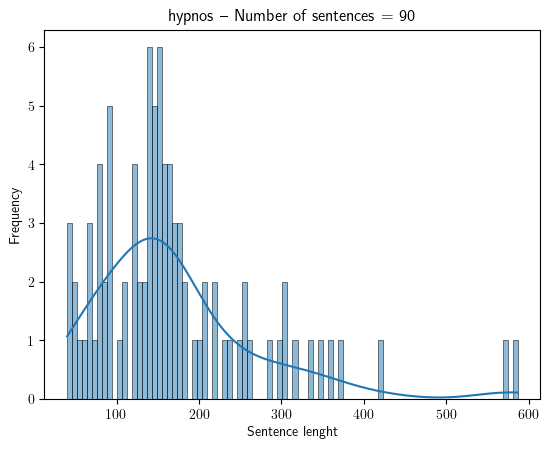

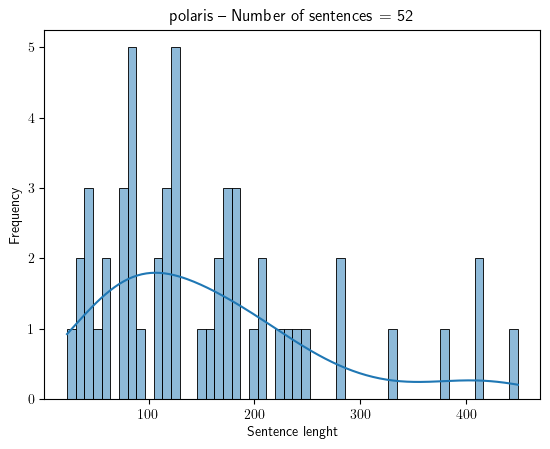

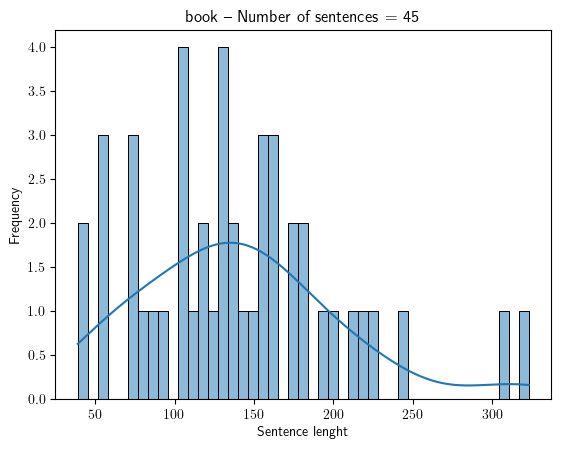

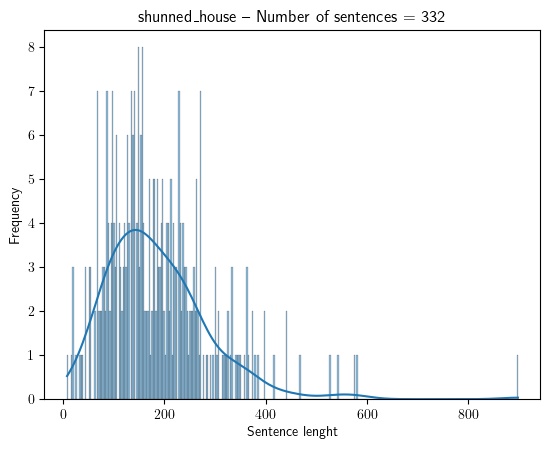

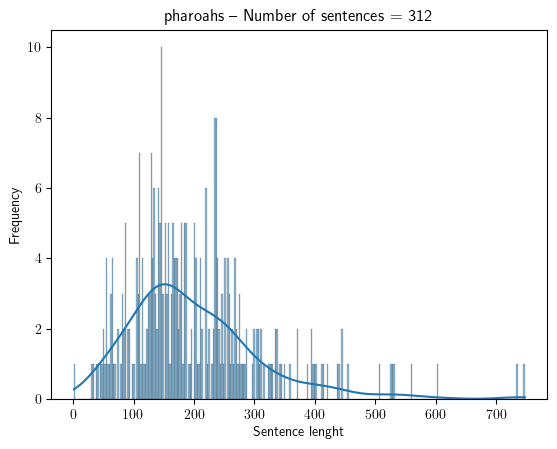

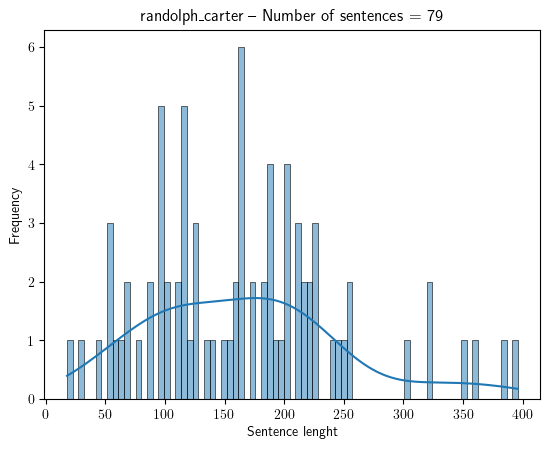

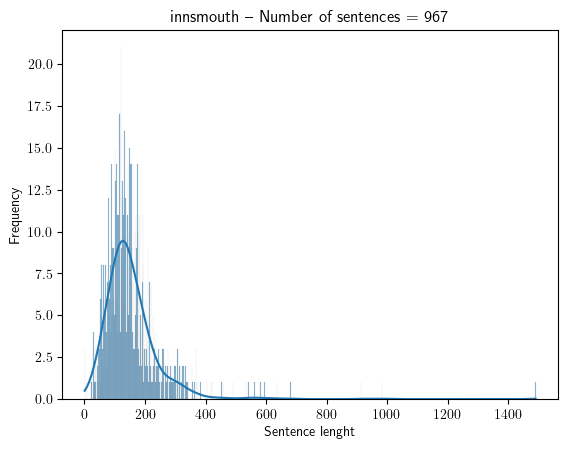

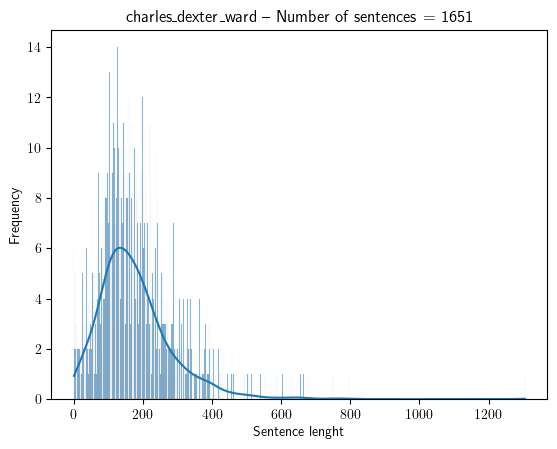

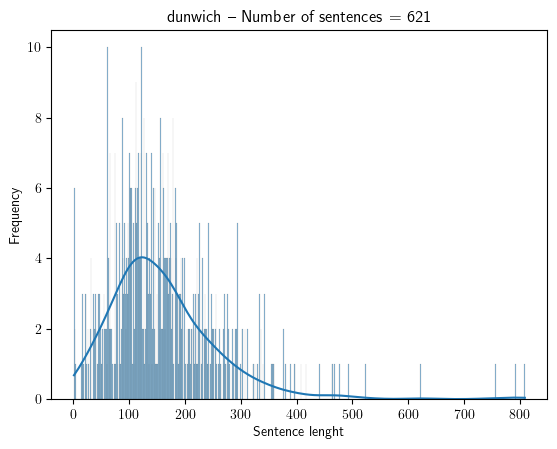

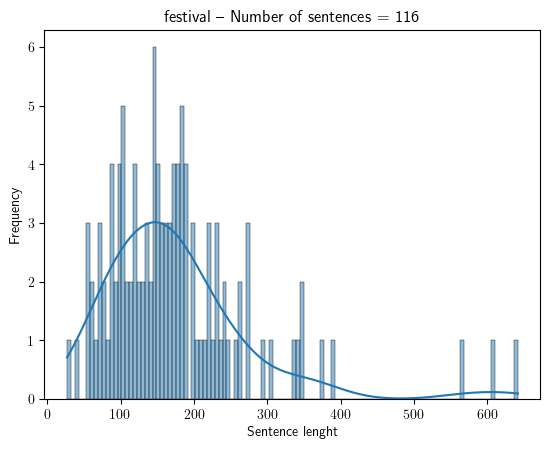

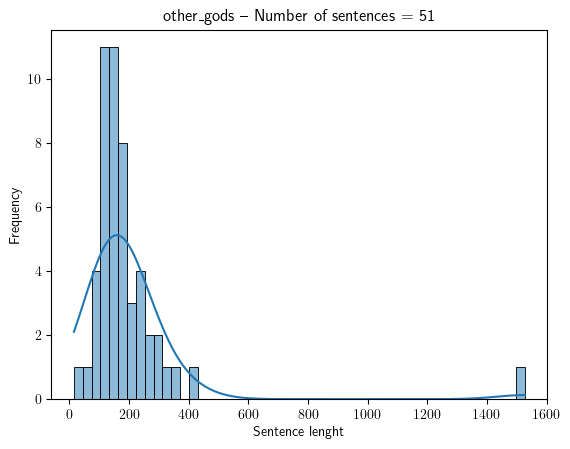

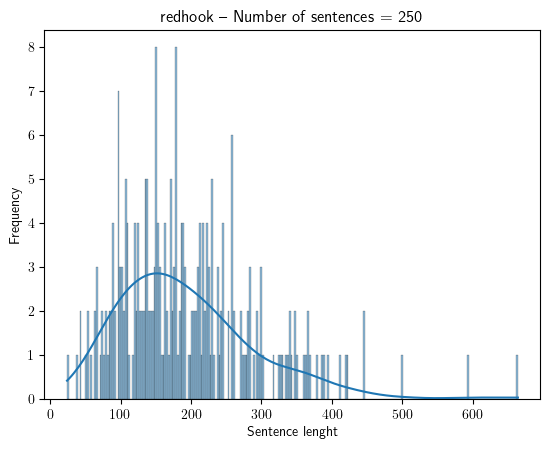

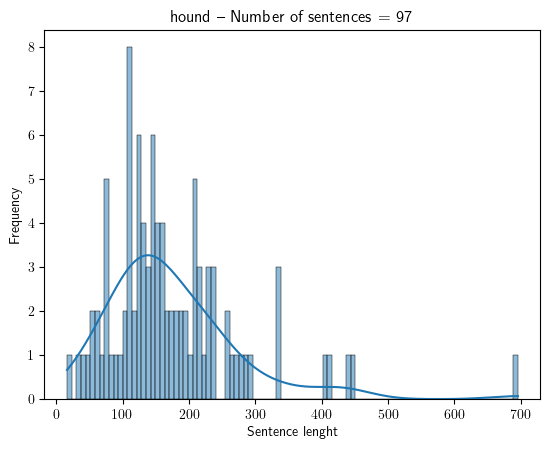

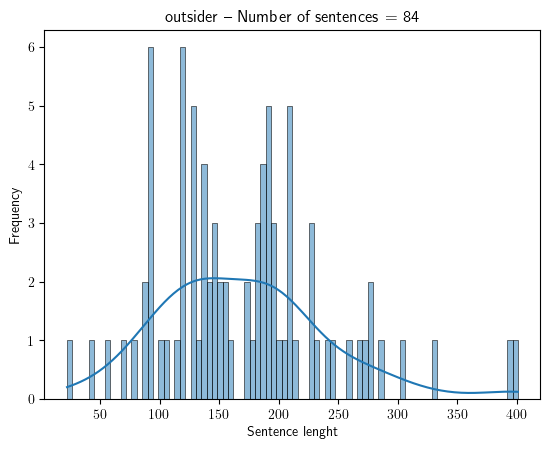

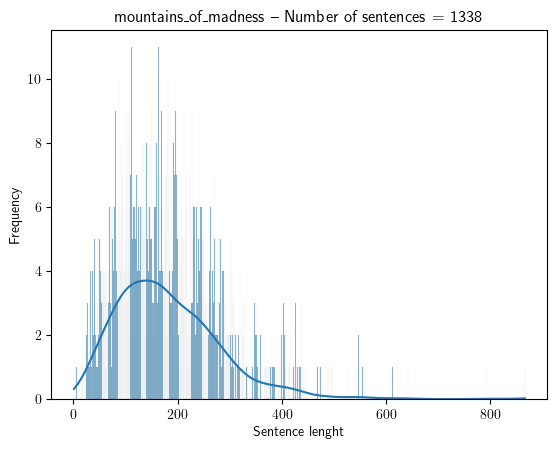

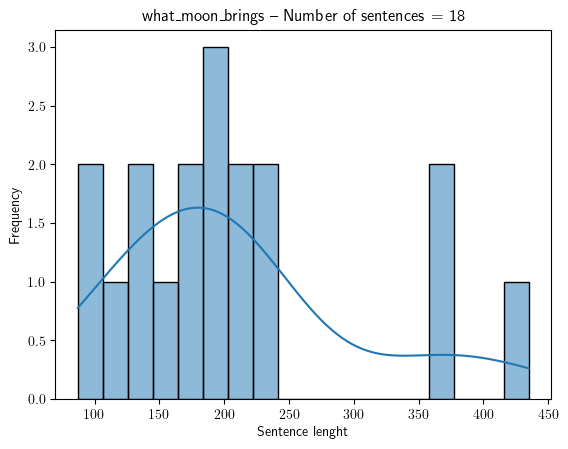

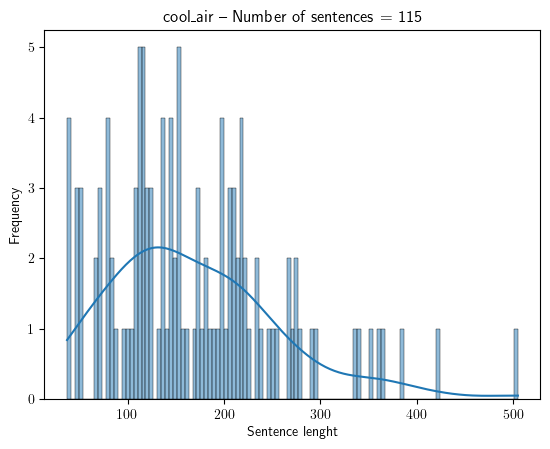

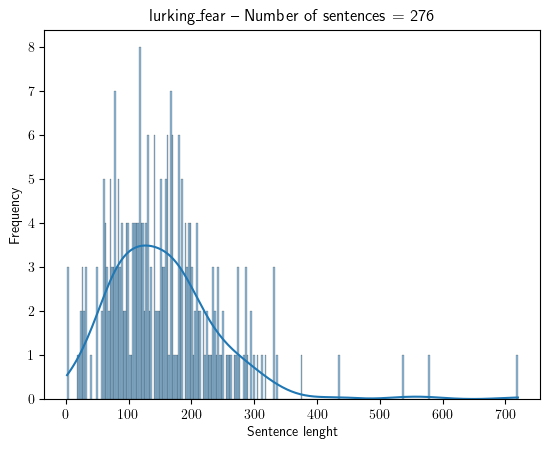

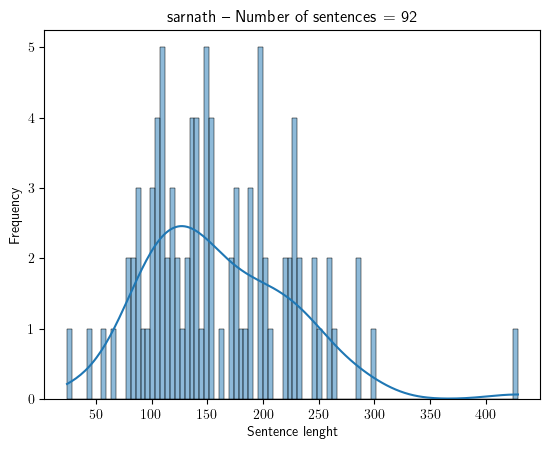

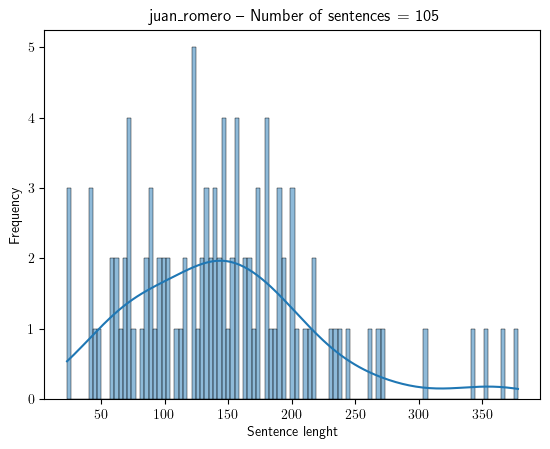

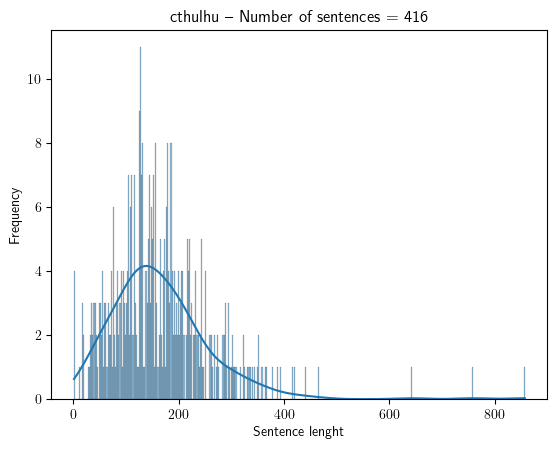

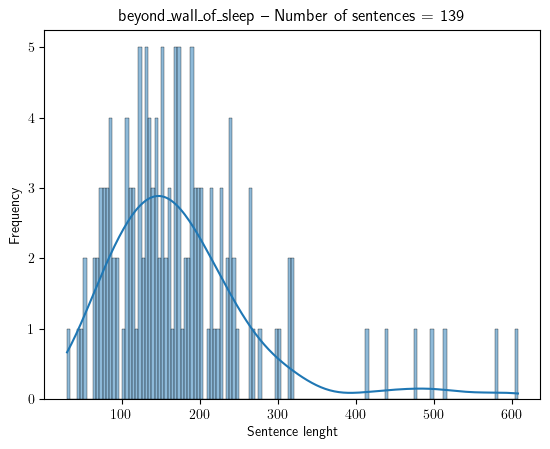

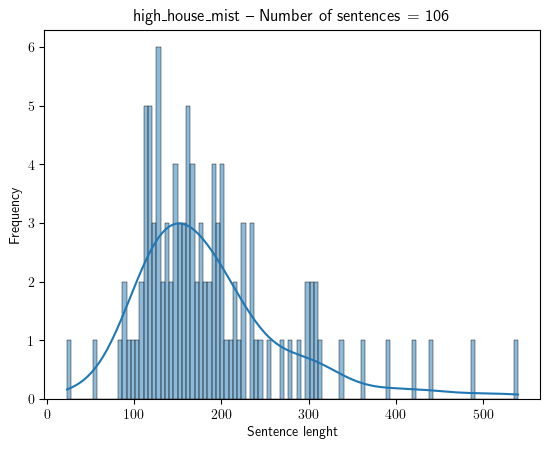

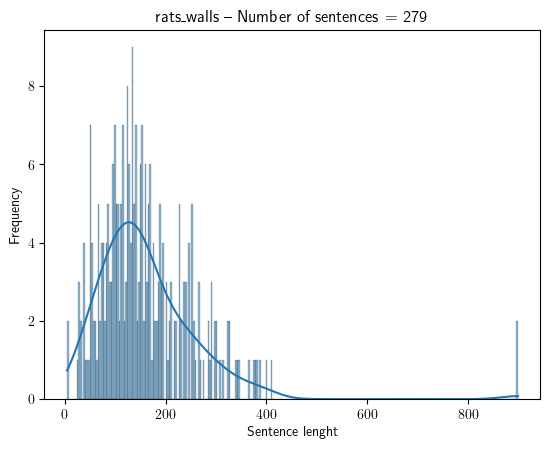

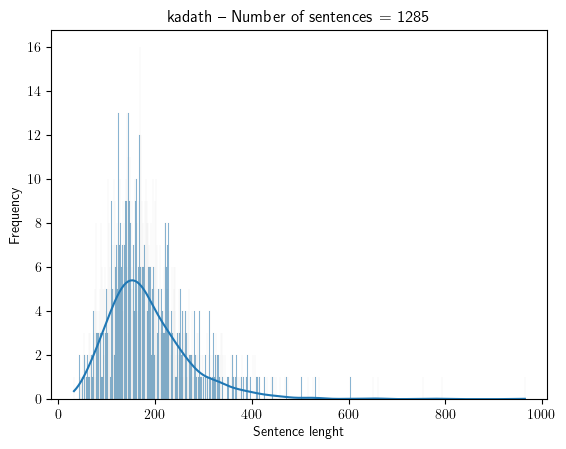

In [17]:
for story, sentence_lenghts in lenghts.items():
    sns.histplot(sentence_lenghts, bins=len(sentence_lenghts), kde = True)
    plt.title(f'{story} -- Number of sentences = {len(sentence_lenghts)}')
    plt.xlabel('Sentence lenght')
    plt.ylabel('Frequency')
    plt.savefig(f'plots/sentence_lenght/sentence_lenght_distribution_{story}.png')
    plt.show()

### 2.1 The Call of Cthulhu

Using $\tt biblio.sentences$ which a dictionary where the key is the story name and the value is a list with every phrase on the text, we create a new list called $\tt cthulhu\_lens$ with the number of characters of every sentence in the story.

In [13]:
cthulhu_lens = [ len(phrase) for phrase in biblio.sentences['cthulhu'] ]
#cthulhu_lens_filtered = [length for length in cthulhu_lens if length > 43]
print(cthulhu_lens)

[419, 131, 126, 343, 127, 109, 145, 185, 139, 159, 199, 214, 72, 324, 224, 115, 218, 217, 139, 132, 333, 125, 228, 242, 153, 121, 181, 169, 81, 158, 152, 111, 35, 51, 56, 1, 1, 40, 181, 275, 112, 70, 202, 291, 185, 128, 153, 96, 194, 218, 242, 179, 130, 167, 176, 289, 95, 240, 124, 331, 181, 379, 90, 213, 158, 184, 127, 151, 224, 112, 156, 73, 150, 132, 190, 260, 164, 260, 172, 109, 295, 194, 148, 203, 151, 50, 192, 223, 62, 250, 198, 49, 112, 52, 115, 143, 106, 137, 236, 176, 186, 129, 100, 2, 188, 349, 143, 297, 251, 83, 153, 84, 94, 416, 303, 85, 301, 179, 174, 220, 207, 252, 156, 119, 176, 200, 221, 237, 287, 132, 386, 185, 294, 157, 117, 128, 179, 205, 234, 288, 164, 98, 220, 198, 128, 179, 262, 165, 141, 139, 264, 157, 141, 106, 288, 125, 247, 144, 49, 59, 230, 164, 156, 216, 228, 112, 129, 118, 115, 125, 336, 195, 208, 261, 18, 75, 220, 76, 185, 68, 223, 132, 88, 162, 186, 126, 127, 138, 177, 316, 110, 30, 55, 127, 37, 33, 103, 76, 82, 78, 114, 183, 71, 200, 148, 88, 127, 178, 8

Now we plot the distributions in a histogram. The lenght of characters is in the x-axis and in the y-axis is the number of sentences with that many characters. 

Text(0.5, 1.0, 'Distribution of number of characters for each sentence in Call of Cthulhu')

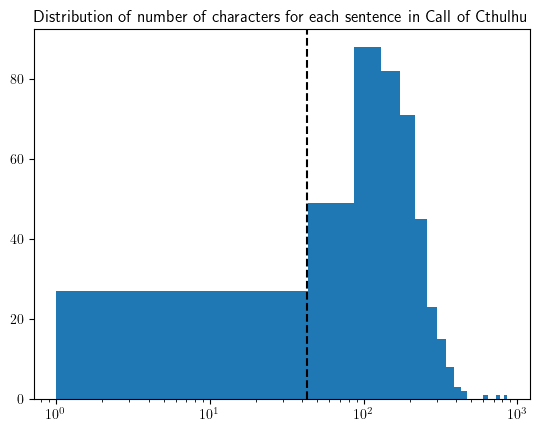

In [14]:
plt.hist(cthulhu_lens, bins = 20)
plt.xscale('log')
plt.axvline(x=43, linestyle = 'dashed', color = 'black')
plt.title('Distribution of number of characters for each sentence in Call of Cthulhu')

We note that there are a constant piece (the one right before the black-dashed vertical line) that is quite strange. Verifying the minimum of the $\tt cthulhu\_lens$ we note the following

In [15]:
print(min(cthulhu_lens))

1


That is, our function that split the text into sentences let some exepctions pass, which are only letters. Thus, we filter this part in order to have a better histogram

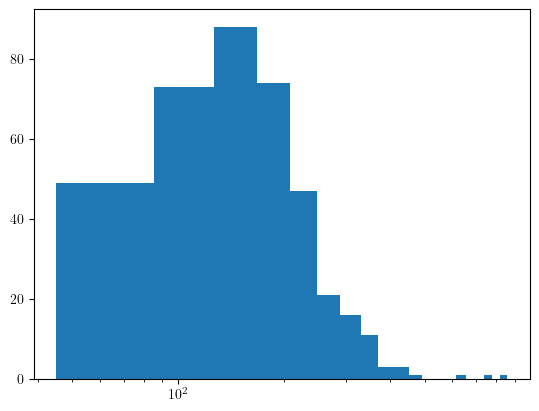

In [16]:
cthulhu_lens = [len(phrase) for phrase in biblio.sentences['cthulhu']]
#Filter out lengths <= 43
cthulhu_lens_filtered = [length for length in cthulhu_lens if length > 43]

plt.hist(cthulhu_lens_filtered, bins=20)
plt.xscale('log') 